# Exp 08 Baseline: Temporal Graph Convolutional Learning Baseline

## Metadata & Scientific Context
| Property | Specification |
| :--- | :--- |
| **Scientific Objective** | Train dynamic graph convolutional networks with temporal recurrent / self-attention layers on windowed connectomes. |
| **Reproducibility Status** | `Verified Executed Outputs Retained` |
| **Input Data Required** | Windowed dynamic graphs and diagnostic labels. |
| **Primary Verified Artifacts** | `Baseline temporal GCN training curves and evaluation metrics.` |
| **Execution Environment** | `Track A / Track C Baseline.` |

> [!NOTE]
> **Audit & Provenance Notice:** This notebook contains executed outputs preserved directly from the original scientific investigation. Paths have been made portable via environment variables (`ADHD200_*`). All numerical metrics and figures reflect the audited research artifacts.



# Subject-wise Train / Validation / Test Split

Multiple dynamic connectivity windows originate from the same subject.

To prevent information leakage, all graphs belonging to one subject are
assigned to the same dataset split.

This subject-wise partition is reused throughout every experiment in
this project.

In [18]:
from collections import defaultdict
subject_to_indices = defaultdict(list)
for idx, graph in enumerate(raw_graphs):
    subject_to_indices[graph.subject_id].append(idx)

print(f"Subjects : {len(subject_to_indices)}")
print(f"Graphs   : {len(raw_graphs)}")

Subjects : 764
Graphs   : 31060


In [19]:
subjects = sorted(subject_to_indices.keys())
print(subjects[:10])

['10001', '10002', '10003', '10004', '10005', '10006', '10007', '10008', '1000804', '10009']


In [20]:
from sklearn.model_selection import train_test_split

train_subjects, temp_subjects = train_test_split(
    subjects,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

In [21]:
train_idx = []
val_idx = []
test_idx = []

for s in train_subjects:
    train_idx.extend(subject_to_indices[s])

for s in val_subjects:
    val_idx.extend(subject_to_indices[s])

for s in test_subjects:
    test_idx.extend(subject_to_indices[s])

In [22]:
assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

print("✓ Subject leakage check passed")

✓ Subject leakage check passed


In [23]:
print("Training subjects :", len(train_subjects))
print("Validation subjects :", len(val_subjects))
print("Test subjects :", len(test_subjects))

print()

print("Training graphs :", len(train_idx))
print("Validation graphs :", len(val_idx))
print("Test graphs :", len(test_idx))

Training subjects : 534
Validation subjects : 115
Test subjects : 115

Training graphs : 21496
Validation graphs : 4887
Test graphs : 4677


In [24]:
import json

split = {
    "train_subjects": train_subjects,
    "validation_subjects": val_subjects,
    "test_subjects": test_subjects,
}

with open(OUTPUT_DIR / "subject_split.json", "w") as f:
    json.dump(split, f, indent=2)

print("✓ Split saved")

✓ Split saved


In [25]:
from collections import Counter

train_labels = Counter(raw_graphs[i].y.item() for i in train_idx)
val_labels = Counter(raw_graphs[i].y.item() for i in val_idx)
test_labels = Counter(raw_graphs[i].y.item() for i in test_idx)

print(train_labels)
print(val_labels)
print(test_labels)

Counter({0: 12689, 1: 8807})
Counter({0: 3278, 1: 1609})
Counter({0: 3137, 1: 1540})


# Compute class weights

In [60]:
from collections import Counter
train_counter = Counter(g.y.item() for g in train_graphs)
print(train_counter)

Counter({0: 13283, 1: 8478})


In [62]:
import torch
train_counts = torch.tensor(
    [
        train_counter[0],
        train_counter[1]
    ],
    dtype=torch.float32
)
weights = train_counts.sum() / (2 * train_counts)
weights = weights.to(DEVICE)

print("Counts :", train_counts)
print("Weights:", weights)

Counts : tensor([13283.,  8478.])
Weights: tensor([0.8191, 1.2834], device='cuda:0')


In [63]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score
)

import numpy as np

In [64]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0
    predictions = []
    labels = []
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        pred = logits.argmax(dim=1)
        predictions.extend(pred.cpu().numpy())
        labels.extend(batch.y.cpu().numpy())
    epoch_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(labels, predictions)
    return epoch_loss, accuracy

In [98]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0

    predictions = []
    probabilities = []
    labels = []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        loss = criterion(logits, batch.y)
        total_loss += loss.item() * batch.num_graphs
        probs = torch.softmax(logits, dim=1)[:, 1]
        pred = logits.argmax(dim=1)
        predictions.extend(pred.cpu().numpy())
        probabilities.extend(probs.cpu().numpy())
        labels.extend(batch.y.cpu().numpy())

    loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(labels, predictions)
    balanced_acc = balanced_accuracy_score(
        labels,
        predictions
    )
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )
    auc = roc_auc_score(labels, probabilities)
    cm = confusion_matrix(labels, predictions)
    return {
        "loss": loss,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm
    }

In [99]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    epochs,
    device
):

    history = []
    best_state = None
    best_val = 0
    patience = 10
    wait = 0
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        metrics = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step(metrics["balanced_accuracy"])

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            **metrics
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {train_loss:.4f} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Loss {metrics['loss']:.4f} | "
            f"Val Bal Acc {metrics['balanced_accuracy']:.4f} | "
            f"Val F1 {metrics['f1']:.4f}"
        )
        if metrics["balanced_accuracy"] > best_val:
            best_val = metrics["balanced_accuracy"]
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping")
                break
    model.load_state_dict(best_state)
    return history

In [100]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0.0
    total_graphs = 0

    predictions = []
    labels = []

    progress = tqdm(
        loader,
        desc="Training",
        leave=False,
        unit="batch"
    )

    for i, batch in enumerate(progress):

        batch = batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(batch)
            loss = criterion(logits, batch.y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs

        preds = logits.argmax(dim=1)

        predictions.extend(preds.detach().cpu().numpy())
        labels.extend(batch.y.detach().cpu().numpy())

        if i % 10 == 0:
            progress.set_postfix(
                loss=f"{total_loss/total_graphs:.4f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}"
            )

    epoch_loss = total_loss / total_graphs
    epoch_acc = accuracy_score(labels, predictions)

    return epoch_loss, epoch_acc

In [94]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    epochs=EPOCHS,
    device=DEVICE
)

Epoch 001 | Train Loss 0.2154 | Train Acc 0.9216 | Val Loss 0.8473 | Val Bal Acc 0.6328 | Val F1 0.5380


Epoch 002 | Train Loss 0.1786 | Train Acc 0.9352 | Val Loss 0.9454 | Val Bal Acc 0.6350 | Val F1 0.5674


Epoch 003 | Train Loss 0.1603 | Train Acc 0.9425 | Val Loss 0.9794 | Val Bal Acc 0.6244 | Val F1 0.5270


Epoch 004 | Train Loss 0.1255 | Train Acc 0.9582 | Val Loss 1.0574 | Val Bal Acc 0.6202 | Val F1 0.5208


Epoch 005 | Train Loss 0.1073 | Train Acc 0.9656 | Val Loss 1.1380 | Val Bal Acc 0.6147 | Val F1 0.4947


...

Epoch 008 | Train Loss 0.0653 | Train Acc 0.9819 | Val Loss 1.5751 | Val Bal Acc 0.5753 | Val F1 0.3752


Epoch 009 | Train Loss 0.0754 | Train Acc 0.9758 | Val Loss 1.3143 | Val Bal Acc 0.6142 | Val F1 0.5156


Epoch 010 | Train Loss 0.0548 | Train Acc 0.9867 | Val Loss 1.3702 | Val Bal Acc 0.5990 | Val F1 0.4787


Epoch 011 | Train Loss 0.0491 | Train Acc 0.9879 | Val Loss 1.3693 | Val Bal Acc 0.6078 | Val F1 0.5045


Epoch 012 | Train Loss 0.0446 | Train Acc 0.9907 | Val Loss 1.3972 | Val Bal Acc 0.6171 | Val F1 0.5291
Early stopping


In [101]:
test_metrics = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print("Test Results")
print("----------------")

for k, v in test_metrics.items():
    if k != "confusion_matrix":
        print(f"{k:20s}: {v:.4f}")

print("\nConfusion Matrix")
print(test_metrics["confusion_matrix"])

Test Results
----------------
loss                : 1.2331
accuracy            : 0.5443
balanced_accuracy   : 0.5340
precision           : 0.3991
recall              : 0.4958
f1                  : 0.4422
auc                 : 0.5534

Confusion Matrix
[[1661 1242]
 [ 839  825]]


In [102]:
from collections import Counter

train_sites = Counter(g.site for g in train_graphs)
val_sites = Counter(g.site for g in val_graphs)
test_sites = Counter(g.site for g in test_graphs)

print("Train")
print(train_sites)

print("\nValidation")
print(val_sites)

print("\nTest")
print(test_sites)

Train
Counter({'NYU': 7975, 'Peking_1': 2419, 'Pittsburgh': 2145, 'WashU': 1968, 'Peking_2': 1927, 'OHSU': 1509, 'Peking_3': 1394, 'NeuroIMAGE': 1380, 'KKI': 1044})

Validation
Counter({'NYU': 1653, 'Peking_1': 574, 'WashU': 514, 'Pittsburgh': 429, 'KKI': 377, 'Peking_2': 369, 'NeuroIMAGE': 368, 'OHSU': 243, 'Peking_3': 205})

Test
Counter({'NYU': 1798, 'Peking_1': 492, 'NeuroIMAGE': 460, 'Peking_2': 451, 'OHSU': 378, 'Pittsburgh': 330, 'KKI': 301, 'WashU': 234, 'Peking_3': 123})


## Subject-Level Dynamic Graph Representation Learning

The previous workflow demonstrated that temporal variability of graph
metrics contains more diagnostic information than temporal averages.

The objective of this workflow is therefore to preserve the complete
sequence of dynamic brain graphs for each subject and learn a subject-level
representation directly from these graph sequences.

The first step is to reorganize the existing graph dataset from
graph-level samples into subject-level sequences.

In [103]:
print(f"Total graphs : {len(graphs)}")
print()
example = graphs[0]
print(example)

Total graphs : 31060

Data(x=[190, 190], edge_index=[2, 7182], edge_attr=[7182], y=[1], subject_id='10001', acquisition_id='10001_S1_R1', site='NYU', session=1, run=1, window_index=0, graph_id=0)


## Step 1: Inspect Graph Metadata

Before constructing subject sequences, we first inspect the metadata
stored in each graph object.

Specifically, we verify whether each graph contains identifiers such as

- subject ID
- window index
- acquisition site
- session
- run

These identifiers are required to reconstruct each subject's temporal
graph sequence correctly.

In [14]:
print("Available graph attributes:\n")

for key in graphs[0].keys():
    print(key)

Available graph attributes:

window_index
acquisition_id
edge_index
session
run
x
subject_id
site
y
graph_id
edge_attr


In [15]:
g = graphs[0]
for key in g.keys():
    print(f"{key:20s} : {g[key]}")

window_index         : 0
acquisition_id       : 10001_S1_R1
edge_index           : tensor([[  0,   0,   0,  ..., 187, 188, 189],
        [  2,  10,  14,  ..., 186, 187, 187]])
session              : 1
run                  : 1
x                    : tensor([[ 1.0000,  0.0603, -0.6018,  ..., -0.2971,  0.1737, -0.7175],
        [ 0.0603,  1.0000, -0.3656,  ..., -0.7566, -0.4650, -0.2703],
        [-0.6018, -0.3656,  1.0000,  ...,  0.3886,  0.2400,  0.7440],
        ...,
        [-0.2971, -0.7566,  0.3886,  ...,  1.0000,  0.7407,  0.6556],
        [ 0.1737, -0.4650,  0.2400,  ...,  0.7407,  1.0000,  0.3774],
        [-0.7175, -0.2703,  0.7440,  ...,  0.6556,  0.3774,  1.0000]])
subject_id           : 10001
site                 : NYU
y                    : tensor([1])
graph_id             : 0
edge_attr            : tensor([-0.6018,  0.6820,  0.5877,  ...,  0.6392,  0.7407,  0.6556])


## Step 2: Group Graphs by Subject

The current dataset contains one graph per dynamic connectivity window.

However, ADHD is a subject-level diagnosis rather than a window-level label.

The first step toward subject-level learning is therefore to group all
graphs belonging to the same subject while preserving their metadata.

In [16]:
from collections import defaultdict
subject_graphs = defaultdict(list)
for graph in graphs:
    subject_graphs[graph.subject_id].append(graph)

print(f"Total subjects : {len(subject_graphs)}")

Total subjects : 764


## Step 3: Verify Subject-Level Graph Counts

Before constructing temporal sequences, we verify that every subject
contains the expected number of graph windows.

Large differences may indicate incomplete acquisitions or preprocessing
issues and should be investigated before model development.

In [17]:
graph_counts = {
    sid: len(glist)
    for sid, glist in subject_graphs.items()
}

counts = list(graph_counts.values())

print(f"Minimum graphs : {min(counts)}")
print(f"Maximum graphs : {max(counts)}")
print(f"Average graphs : {sum(counts)/len(counts):.2f}")

Minimum graphs : 9
Maximum graphs : 60
Average graphs : 40.65


In [18]:
from collections import Counter
Counter(counts)

Counter({41: 194,
         58: 179,
         33: 88,
         27: 75,
         19: 54,
         46: 48,
         29: 36,
         60: 32,
         24: 30,
         20: 13,
         40: 8,
         54: 4,
         36: 2,
         9: 1})

## Step 4: Preserve Temporal Ordering
Graphs belonging to the same subject must be ordered chronologically.
The temporal order is reconstructed using the stored window index.

In [19]:
for sid in subject_graphs:
    subject_graphs[sid] = sorted(
        subject_graphs[sid],
        key=lambda g: g.window_index
    )

In [20]:
sample_subject = next(iter(subject_graphs))

print("Subject:", sample_subject)
print()

for graph in subject_graphs[sample_subject][:5]:
    print(
        f"Window {graph.window_index:2d} | "
        f"Session {graph.session} | "
        f"Run {graph.run}"
    )

Subject: 10001

Window  0 | Session 1 | Run 1
Window  0 | Session 1 | Run 2
Window  1 | Session 1 | Run 1
Window  1 | Session 1 | Run 2
Window  2 | Session 1 | Run 1


## Step 5: Validate Acquisition Structure

Some subjects contain multiple acquisition runs. Therefore, the temporal
ordering of graphs cannot be reconstructed using the window index alone.

Before constructing subject sequences, we inspect the acquisition
structure for representative subjects.

In [21]:
sample_subject = next(iter(subject_graphs))

subject = subject_graphs[sample_subject]

for g in sorted(subject, key=lambda x: (x.session, x.run, x.window_index)):
    print(
        f"Session={g.session} "
        f"Run={g.run} "
        f"Window={g.window_index:2d}"
    )

Session=1 Run=1 Window= 0
Session=1 Run=1 Window= 1
Session=1 Run=1 Window= 2
Session=1 Run=1 Window= 3
Session=1 Run=1 Window= 4
Session=1 Run=1 Window= 5
Session=1 Run=1 Window= 6
Session=1 Run=1 Window= 7
Session=1 Run=1 Window= 8
Session=1 Run=1 Window= 9
Session=1 Run=1 Window=10
Session=1 Run=1 Window=11
Session=1 Run=1 Window=12
Session=1 Run=1 Window=13
Session=1 Run=1 Window=14
Session=1 Run=1 Window=15
Session=1 Run=1 Window=16
Session=1 Run=1 Window=17
Session=1 Run=1 Window=18
Session=1 Run=1 Window=19
Session=1 Run=1 Window=20
Session=1 Run=1 Window=21
Session=1 Run=1 Window=22
Session=1 Run=1 Window=23
Session=1 Run=1 Window=24
Session=1 Run=1 Window=25
Session=1 Run=1 Window=26
Session=1 Run=1 Window=27
Session=1 Run=1 Window=28
Session=1 Run=2 Window= 0
Session=1 Run=2 Window= 1
Session=1 Run=2 Window= 2
Session=1 Run=2 Window= 3
Session=1 Run=2 Window= 4
Session=1 Run=2 Window= 5
Session=1 Run=2 Window= 6
Session=1 Run=2 Window= 7
Session=1 Run=2 Window= 8
Session=1 Ru

## Step 6: Construct Ordered Subject Sequences

Graphs are now reordered using

1. Session
2. Run
3. Window Index

This guarantees that every subject is represented by an ordered sequence
of dynamic brain graphs corresponding to the original acquisition order.

In [22]:
for sid in subject_graphs:
    subject_graphs[sid] = sorted(
        subject_graphs[sid],
        key=lambda g: (
            g.session,
            g.run,
            g.window_index
        )
    )

## Step 7: Create Subject-Level Data Structure

Each subject is represented as a single sample containing

- ordered graph sequence
- diagnosis
- acquisition site
- number of graph windows

This structure forms the input to subsequent graph representation
learning models.

In [59]:
subject_sequences = {}
for sid, graph_list in subject_graphs.items():
    subject_sequences[sid] = {
        "graphs": graph_list,
        "label": graph_list[0].y.item(),
        "site": graph_list[0].site,
        "num_windows": len(graph_list),
        "session_ids": sorted(
            list({g.session for g in graph_list})
        ),
        "run_ids": sorted(
            list({g.run for g in graph_list})
        )
    }
print(f"Created {len(subject_sequences)} subject sequences.")

Created 764 subject sequences.


In [60]:
sample = next(iter(subject_sequences.values()))

print("Label:", sample["label"])
print("Site:", sample["site"])
print("Number of windows:", sample["num_windows"])
print("Sessions:", sample["session_ids"])
print("Runs:", sample["run_ids"])

Label: 1
Site: NYU
Number of windows: 58
Sessions: [1]
Runs: [1, 2]


In [25]:
inconsistent = []
for sid, graph_list in subject_graphs.items():
    labels = {g.y.item() for g in graph_list}
    if len(labels) > 1:
        inconsistent.append(sid)
print(f"Inconsistent subjects: {len(inconsistent)}")
if inconsistent:
    print(inconsistent[:10])

Inconsistent subjects: 0


In [26]:
inconsistent = []
for sid, graph_list in subject_graphs.items():
    sites = {g.site for g in graph_list}
    if len(sites) > 1:
        inconsistent.append(sid)

print(f"Inconsistent sites: {len(inconsistent)}")

Inconsistent sites: 0


In [27]:
from collections import Counter
run_distribution = Counter()
for sample in subject_sequences.values():
    run_distribution[len(sample["run_ids"])] += 1

run_distribution

Counter({1: 463, 2: 187, 3: 108, 6: 4, 4: 2})

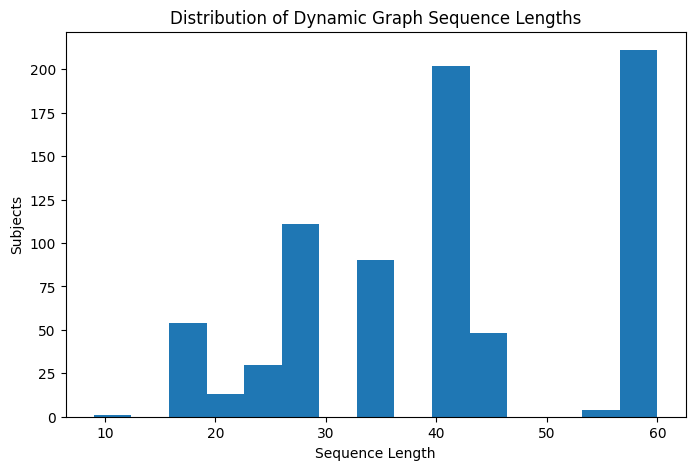

In [118]:
import matplotlib.pyplot as plt

lengths = [
    sample["num_windows"]
    for sample in subject_sequences.values()
]

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=15)
plt.xlabel("Sequence Length")
plt.ylabel("Subjects")
plt.title("Distribution of Dynamic Graph Sequence Lengths")
plt.show()

# Graph Representation Learning

The dataset has now been reorganized into subject-level sequences of
dynamic functional connectivity graphs.

The next objective is to learn a low-dimensional representation for
each graph using a shared graph neural network.

Each graph is independently encoded into a latent embedding while
sharing the same encoder parameters across all temporal windows.

These graph embeddings will subsequently be used for temporal
representation learning.

# Graph Encoder

Each subject is represented by an ordered sequence of functional brain
graphs. The first stage of the proposed architecture is to encode every
graph into a compact latent representation using a shared Graph
Convolutional Network (GCN).

The same encoder is applied independently to every graph in every
subject sequence.

This stage transforms

Graph → Graph Embedding

while preserving the temporal ordering of the graph sequence for later
temporal modeling.

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GCNConv,
    global_mean_pool
)

## Define the Graph Encoder

The graph encoder consists of two graph convolution layers followed by
global mean pooling.

The convolution layers learn node-level representations, while global
pooling aggregates these node representations into a single embedding
describing the entire functional connectivity graph.

In [225]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GCNConv,
    global_mean_pool
)


class GraphEncoder(nn.Module):
    def __init__(
        self,
        in_channels=190,
        hidden_channels=64,
        embedding_dim=64,
        dropout=0.3,
    ):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            embedding_dim
        )

        self.dropout = dropout

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        batch = getattr(
            data,
            "batch",
            torch.zeros(
                x.size(0),
                dtype=torch.long,
                device=x.device
            )
        )

        # Ignore edge weights temporarily
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        embedding = global_mean_pool(
            x,
            batch
        )

        return embedding

## Instantiate the Encoder

A graph encoder is created with the architecture

190 → 64 → 32

where

- 190 is the node feature dimension,
- 64 is the hidden representation,
- 32 is the final graph embedding dimension.

In [226]:
graph_encoder = GraphEncoder()
graph_encoder

GraphEncoder(
  (conv1): GCNConv(190, 64)
  (conv2): GCNConv(64, 64)
)

In [227]:
graph_encoder.eval()
sample_graph = graphs[0]
with torch.no_grad():
    embedding = graph_encoder(sample_graph)

print("Embedding shape :", embedding.shape)
print()
print(embedding)

Embedding shape : torch.Size([1, 64])

tensor([[ 0.0703, -0.0577, -0.0827,  0.0669, -0.0359, -0.0089, -0.0357, -0.0814,
         -0.0002,  0.0287,  0.0123,  0.0425, -0.0168, -0.0679, -0.0779, -0.0590,
          0.0800,  0.0028,  0.0405,  0.0350,  0.0696, -0.0045, -0.0427, -0.0595,
          0.0754,  0.0238, -0.0125, -0.0614,  0.0077,  0.0341, -0.0841, -0.0178,
         -0.0370,  0.0973,  0.0023, -0.0629,  0.0038,  0.0002, -0.0191,  0.0234,
         -0.0301, -0.0252,  0.0325,  0.0461,  0.0376, -0.0309, -0.0201,  0.0588,
          0.0262, -0.0354, -0.0391,  0.0662, -0.0069,  0.0579,  0.0438, -0.0210,
          0.0099,  0.0370, -0.0144,  0.0210,  0.0656, -0.0141,  0.0148, -0.0089]])


In [228]:
x = sample_graph.x

print("Contains NaN :", torch.isnan(x).any().item())
print("Contains Inf :", torch.isinf(x).any().item())

print("Min :", x.min().item())
print("Max :", x.max().item())
print("Mean:", x.mean().item())

Contains NaN : False
Contains Inf : False
Min : -0.9575052857398987
Max : 1.0
Mean: 0.007381478324532509


In [229]:
edge_weight = sample_graph.edge_attr

print("Contains NaN :", torch.isnan(edge_weight).any().item())
print("Contains Inf :", torch.isinf(edge_weight).any().item())

print("Min :", edge_weight.min().item())
print("Max :", edge_weight.max().item())
print("Mean:", edge_weight.mean().item())

Contains NaN : False
Contains Inf : False
Min : -0.9575052857398987
Max : 0.9746668934822083
Mean: 0.03333837538957596


In [230]:
print("Nodes :", sample_graph.num_nodes)
print("Edges :", sample_graph.num_edges)

print("Self loops:", torch.sum(sample_graph.edge_index[0] == sample_graph.edge_index[1]).item())

Nodes : 190
Edges : 7182
Self loops: 0


In [231]:
conv1 = graph_encoder.conv1

with torch.no_grad():

    x = conv1(
        sample_graph.x,
        sample_graph.edge_index,
        sample_graph.edge_attr
    )

print("NaN after conv1 :", torch.isnan(x).any().item())
print("Inf after conv1 :", torch.isinf(x).any().item())

NaN after conv1 : True
Inf after conv1 : False


# Graph Encoder I: GraphSAGE

The first graph encoder is implemented using GraphSAGE.

Unlike the Graph Convolutional Network (GCN), GraphSAGE aggregates
neighboring node representations without relying on weighted graph
normalization. This makes it suitable for functional connectivity graphs
containing signed edge weights.

Each graph is encoded into a fixed-dimensional embedding that will later
be used for temporal representation learning.

In [232]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    SAGEConv,
    global_mean_pool
)

In [233]:
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import (
    SAGEConv,
    BatchNorm,
    global_mean_pool
)

class GraphSAGEEncoder(nn.Module):

    def __init__(
        self,
        in_channels=190,
        hidden_channels=64,
        embedding_dim=64,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels,
            normalize=True
        )

        self.bn1 = BatchNorm(hidden_channels)

        self.conv2 = SAGEConv(
            hidden_channels,
            embedding_dim,
            normalize=True
        )

        self.bn2 = BatchNorm(embedding_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        """
        Parameters
        ----------
        data : torch_geometric.data.Batch

        Returns
        -------
        Tensor
            Shape: (num_graphs, embedding_dim)
        """

        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        embeddings = global_mean_pool(x, batch)

        return embeddings

In [234]:
print("Embedding mean :", embedding.mean().item())
print("Embedding std  :", embedding.std().item())
print("Embedding min  :", embedding.min().item())
print("Embedding max  :", embedding.max().item())

Embedding mean : 0.0009755929931998253
Embedding std  : 0.045691460371017456
Embedding min  : -0.08412429690361023
Embedding max  : 0.0973338708281517


In [235]:
graph_encoder = GraphSAGEEncoder(
    in_channels=190,
    hidden_channels=64,
    embedding_dim=64
)

graph_encoder.eval()

sample_graph = graphs[0]

with torch.no_grad():
    embedding = graph_encoder(sample_graph)

print(embedding.shape)
print(torch.isnan(embedding).any())
print(torch.isinf(embedding).any())

torch.Size([1, 64])
tensor(False)
tensor(False)


## Encode a Mini-Batch of Graphs

The graph encoder is evaluated on a batch of graphs to verify that it
produces one embedding per graph.

This confirms that the encoder can be integrated into a subject-level
sequence model.

In [236]:
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch.utils.data import DataLoader as TorchDataLoader

In [237]:
test_loader = PyGDataLoader(
    graphs[:8],
    batch_size=8,
    shuffle=False
)
batch = next(iter(test_loader))

batch

DataBatch(x=[1520, 190], edge_index=[2, 57456], edge_attr=[57456], y=[8], subject_id=[8], acquisition_id=[8], site=[8], session=[8], run=[8], window_index=[8], graph_id=[8], batch=[1520], ptr=[9])

In [238]:
with torch.no_grad():
    embeddings = graph_encoder(batch)

print("Embedding shape:", embeddings.shape)

Embedding shape: torch.Size([8, 64])


In [239]:
print(embeddings)

tensor([[7.7302e-03, 7.2555e-03, 1.0752e-01, 1.1387e-01, 9.6591e-02, 4.1950e-04,
         9.3724e-04, 9.4487e-04, 5.2465e-02, 7.9324e-02, 1.9592e-01, 2.2344e-04,
         8.8551e-02, 1.1718e-01, 1.4646e-02, 1.5138e-02, 0.0000e+00, 8.4435e-04,
         3.4308e-05, 2.1429e-01, 3.2619e-04, 2.6333e-02, 1.3296e-03, 1.0890e-02,
         0.0000e+00, 8.5221e-02, 1.7789e-02, 6.7237e-03, 2.9758e-02, 2.2227e-02,
         4.3215e-02, 2.2782e-02, 6.4759e-03, 0.0000e+00, 1.3590e-03, 0.0000e+00,
         0.0000e+00, 2.0316e-02, 0.0000e+00, 4.3133e-02, 8.5228e-02, 8.3439e-02,
         3.3288e-03, 4.3505e-03, 6.0306e-02, 8.2361e-03, 1.5547e-01, 1.0431e-01,
         1.3024e-02, 0.0000e+00, 8.4378e-03, 3.7808e-02, 5.6370e-02, 0.0000e+00,
         3.3762e-03, 2.4840e-03, 6.9713e-05, 2.0760e-03, 2.1948e-03, 1.8097e-01,
         0.0000e+00, 5.7405e-04, 1.9397e-01, 1.6662e-01],
        [1.3757e-02, 2.9526e-03, 1.1633e-01, 1.0205e-01, 8.3779e-02, 7.8331e-04,
         1.1579e-03, 0.0000e+00, 4.6204e-02, 8.0521

In [240]:
print(f"Graphs in batch : {batch.num_graphs}")
print(f"Embedding shape : {embeddings.shape}")

Graphs in batch : 8
Embedding shape : torch.Size([8, 64])


# Positional Encoding

Transformer self-attention is permutation invariant and therefore does not
preserve temporal ordering.

Sinusoidal positional encoding is added to the graph embedding sequence
to encode the temporal position of each dynamic functional connectivity
window.

In [241]:
import math
import torch
import torch.nn as nn


class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=128):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(max_len).float().unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer(
            "pe",
            pe.unsqueeze(0)
        )

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

In [242]:
import torch

def encode_subject(subject, graph_encoder):
    """
    Encode one subject into a sequence of graph embeddings.

    Args:
        subject: subject_sequences[subject_id]
        graph_encoder: trained GraphEncoder

    Returns:
        Tensor of shape (T, embedding_dim)
    """

    graph_encoder.eval()

    graphs = subject["graphs"]

    embeddings = []

    with torch.no_grad():
        for graph in graphs:
            embedding = graph_encoder(graph)      # (1, 64)
            embeddings.append(embedding.squeeze(0))

    return torch.stack(embeddings, dim=0)

In [243]:
sequence = encode_subject(
    subject_sequences["10001"],
    graph_encoder
)

print(sequence.shape)

torch.Size([58, 64])


In [244]:
sequence = sequence.unsqueeze(0)
print(sequence.shape)

torch.Size([1, 58, 64])


In [245]:
import math
import torch
import torch.nn as nn


class PositionalEncoding(nn.Module):
    def __init__(
        self,
        d_model=64,
        dropout=0.1,
        max_len=500,
    ):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32,
            )
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [246]:
position_encoder = PositionalEncoding(d_model=64)
positioned = position_encoder(sequence)
print(positioned.shape)

torch.Size([1, 58, 64])


In [247]:
print(torch.allclose(sequence, positioned))

False


In [248]:
transformer = nn.TransformerEncoder(
    nn.TransformerEncoderLayer(
        d_model=64,
        nhead=4,
        dim_feedforward=256,
        dropout=0.1,
        activation="gelu",
        batch_first=True,
        norm_first=True
    ),
    num_layers=2
)

In [249]:
transformer.eval()
with torch.no_grad():
    temporal_features = transformer(positioned)
print(temporal_features.shape)

torch.Size([1, 58, 64])


In [250]:
print(torch.isnan(temporal_features).any())
print(torch.isinf(temporal_features).any())

tensor(False)
tensor(False)


# Temporal Attention Pooling

The Transformer produces a contextualized embedding for every graph in
the temporal sequence.

A learnable attention pooling layer aggregates these embeddings into a
single subject-level representation by assigning higher weights to
temporally informative windows.

In [251]:
class AttentionPooling(nn.Module):

    def __init__(self, embedding_dim=64):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.Tanh(),
            nn.Linear(embedding_dim, 1)
        )

    def forward(
        self,
        x,
        padding_mask=None
    ):
        """
        Parameters
        ----------
        x : Tensor
            Shape: (batch_size, sequence_length, embedding_dim)

        padding_mask : Tensor, optional
            Shape: (batch_size, sequence_length)

            True indicates padded positions that should be ignored.
        """

        scores = self.attention(x)

        if padding_mask is not None:
            scores = scores.masked_fill(
                padding_mask.unsqueeze(-1),
                float("-inf")
            )

        weights = torch.softmax(
            scores,
            dim=1
        )

        pooled = torch.sum(
            weights * x,
            dim=1
        )

        return pooled, weights

In [252]:
attention_pool = AttentionPooling(
    embedding_dim=64
)

attention_pool.eval()

with torch.no_grad():
    subject_embedding, attention_weights = attention_pool(
        temporal_features
    )

print(subject_embedding.shape)
print(attention_weights.shape)

torch.Size([1, 64])
torch.Size([1, 58, 1])


In [253]:
attention_pool.eval()

with torch.no_grad():

    subject_embedding, attention_weights = attention_pool(
        temporal_features
    )

print(subject_embedding.shape)
print(attention_weights.shape)

torch.Size([1, 64])
torch.Size([1, 58, 1])


In [254]:
print(
    attention_weights.sum(dim=1)
)

tensor([[1.0000]])


In [255]:
print(attention_weights.squeeze())

tensor([0.0195, 0.0180, 0.0156, 0.0114, 0.0117, 0.0133, 0.0132, 0.0151, 0.0219,
        0.0174, 0.0161, 0.0146, 0.0218, 0.0230, 0.0184, 0.0161, 0.0155, 0.0140,
        0.0132, 0.0177, 0.0236, 0.0189, 0.0153, 0.0180, 0.0155, 0.0173, 0.0175,
        0.0156, 0.0124, 0.0107, 0.0124, 0.0160, 0.0186, 0.0167, 0.0208, 0.0132,
        0.0202, 0.0239, 0.0231, 0.0253, 0.0186, 0.0172, 0.0124, 0.0161, 0.0177,
        0.0159, 0.0140, 0.0150, 0.0121, 0.0126, 0.0170, 0.0166, 0.0193, 0.0209,
        0.0166, 0.0211, 0.0284, 0.0258])


In [256]:
print(torch.isnan(subject_embedding).any())
print(torch.isinf(subject_embedding).any())
print(subject_embedding.shape)

tensor(False)
tensor(False)
torch.Size([1, 64])


In [257]:
class Classifier(nn.Module):

    def __init__(
        self,
        embedding_dim=64,
        hidden_dim=32,
        num_classes=2
    ):
        super().__init__()

        self.classifier = nn.Sequential(

            nn.Linear(
                embedding_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                hidden_dim,
                num_classes
            )
        )

    def forward(self, x):
        return self.classifier(x)

In [258]:
classifier = Classifier()
classifier.eval()
with torch.no_grad():
    logits = classifier(subject_embedding)
print(logits.shape)
print(logits)

torch.Size([1, 2])
tensor([[-0.1413, -0.2956]])


# Hybrid Graph Transformer

The complete architecture integrates graph representation learning,
temporal modeling and subject-level classification into a single
end-to-end neural network.

The model consists of

- GraphSAGE graph encoder
- Sinusoidal positional encoding
- Transformer encoder
- Temporal attention pooling
- MLP classifier

In [259]:
from torch.nn.utils.rnn import pad_sequence
from torch_geometric.data import Batch

class HybridGraphTransformer(nn.Module):

    def __init__(
        self,
        node_features=190,
        hidden_channels=64,
        embedding_dim=64,
        transformer_heads=4,
        transformer_layers=2,
        ff_dim=256,
        dropout=0.3,
        num_classes=2
    ):
        super().__init__()

        self.graph_encoder = GraphSAGEEncoder(
            in_channels=node_features,
            hidden_channels=hidden_channels,
            embedding_dim=embedding_dim,
            dropout=dropout
        )

        self.position_encoder = PositionalEncoding(
            d_model=embedding_dim,
            max_len=128
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=transformer_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=transformer_layers
        )

        self.pooling = AttentionPooling(
            embedding_dim=embedding_dim
        )

        self.classifier = Classifier(
            embedding_dim=embedding_dim,
            hidden_dim=embedding_dim // 2,
            num_classes=num_classes
        )

    def forward(self, batch_graphs):
        """
        Parameters
        ----------
        batch_graphs :
            Either

            list[list[Data]]
                (single-subject inference)

            OR

            list[DataBatch]
                (training DataLoader)

        Returns
        -------
        logits :
            (batch_size, num_classes)

        attentions :
            (batch_size, sequence_length, 1)
        """

        device = next(self.parameters()).device

        subject_graph_lists = []

        for subject in batch_graphs:
            if isinstance(subject, Batch):
                subject_graph_lists.append(subject.to_data_list())
            else:
                subject_graph_lists.append(subject)

        lengths = [len(subject) for subject in subject_graph_lists]

        all_graphs = [
            graph
            for subject in subject_graph_lists
            for graph in subject
        ]

        graph_batch = Batch.from_data_list(all_graphs).to(
            device,
            non_blocking=True
        )

        # GraphSAGE encoder
        all_embeddings = self.graph_encoder(graph_batch)

        # Recover temporal sequences
        sequences = torch.split(
            all_embeddings,
            lengths,
            dim=0
        )

        # Pad sequences
        padded_sequences = pad_sequence(
            sequences,
            batch_first=True
        )

        lengths = torch.tensor(
            lengths,
            device=device
        )

        max_len = padded_sequences.size(1)

        padding_mask = (
            torch.arange(max_len, device=device)[None, :]
            >= lengths[:, None]
        )

        # Positional encoding
        padded_sequences = self.position_encoder(
            padded_sequences
        )

        # Transformer encoder
        transformed = self.transformer(
            padded_sequences,
            src_key_padding_mask=padding_mask
        )

        # Attention pooling
        subject_embeddings, attentions = self.pooling(
            transformed,
            padding_mask
        )

        # Classification
        logits = self.classifier(
            subject_embeddings
        )

        return logits, attentions

In [261]:
print(type(labels))

if isinstance(labels, list):
    print("Length:", len(labels))
    print("First element:", type(labels[0]))

<class 'list'>
Length: 764
First element: <class 'int'>


In [262]:
import torch
import torch.nn as nn

# Enable TensorFloat-32 on Ampere/Hopper GPUs
if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

# Build model
model = HybridGraphTransformer().to(device)

# Compile model (works well with the batched forward implementation)
if device.type == "cuda":
    model = torch.compile(model)

# Loss
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
    fused=(device.type == "cuda")
)

# Learning-rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

# BF16 training does not require GradScaler.
# Move data to the device inside the training loop:
#
# for graph_sequences, labels in train_loader:
#     labels = labels.to(device, non_blocking=True)
#
#     with torch.autocast(
#         device_type="cuda",
#         dtype=torch.bfloat16
#     ):
#         logits, attention = model(graph_sequences)
#         loss = criterion(logits, labels)

model

OptimizedModule(
  (_orig_mod): HybridGraphTransformer(
    (graph_encoder): GraphSAGEEncoder(
      (conv1): SAGEConv(190, 64, aggr=mean)
      (bn1): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SAGEConv(64, 64, aggr=mean)
      (bn2): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (position_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.3, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): Laye

## Evaluate End-to-End Forward Pass

The complete architecture is evaluated on a single subject sequence.

The output consists of

- class logits
- temporal attention weights

In [263]:
print("Logits:")
print(logits)

print("\nAttention weights:")
print(attention_weights.squeeze())

print("\nShapes:")
print(f"Logits: {tuple(logits.shape)}")
print(f"Attention: {tuple(attention_weights.shape)}")

print("\nAttention checks:")
print("Attention sums to:", attention_weights.sum(dim=1).squeeze())

print("\nNaN checks:")
print("Logits:", torch.isnan(logits).any().item())
print("Attention:", torch.isnan(attention_weights).any().item())

print("\nInf checks:")
print("Logits:", torch.isinf(logits).any().item())
print("Attention:", torch.isinf(attention_weights).any().item())

print("\nAttention statistics:")
print(f"Min : {attention_weights.min().item():.6f}")
print(f"Max : {attention_weights.max().item():.6f}")
print(f"Mean: {attention_weights.mean().item():.6f}")

Logits:
tensor([[-0.1413, -0.2956]])

Attention weights:
tensor([0.0195, 0.0180, 0.0156, 0.0114, 0.0117, 0.0133, 0.0132, 0.0151, 0.0219,
        0.0174, 0.0161, 0.0146, 0.0218, 0.0230, 0.0184, 0.0161, 0.0155, 0.0140,
        0.0132, 0.0177, 0.0236, 0.0189, 0.0153, 0.0180, 0.0155, 0.0173, 0.0175,
        0.0156, 0.0124, 0.0107, 0.0124, 0.0160, 0.0186, 0.0167, 0.0208, 0.0132,
        0.0202, 0.0239, 0.0231, 0.0253, 0.0186, 0.0172, 0.0124, 0.0161, 0.0177,
        0.0159, 0.0140, 0.0150, 0.0121, 0.0126, 0.0170, 0.0166, 0.0193, 0.0209,
        0.0166, 0.0211, 0.0284, 0.0258])

Shapes:
Logits: (1, 2)
Attention: (1, 58, 1)

Attention checks:
Attention sums to: tensor(1.0000)

NaN checks:
Logits: False
Attention: False

Inf checks:
Logits: False
Attention: False

Attention statistics:
Min : 0.010702
Max : 0.028433
Mean: 0.017241


In [264]:
graphs = subject_sequences["10001"]["graphs"]
print(type(graphs[0]))
print(type(graphs[0]).__module__)

<class 'torch_geometric.data.data.Data'>
torch_geometric.data.data


In [265]:
from sklearn.model_selection import train_test_split

In [266]:
subject_ids = list(subject_sequences.keys())

labels = [
    subject_sequences[sid]["label"]
    for sid in subject_ids
]

print("Subjects:", len(subject_ids))
print("Labels:", len(labels))

Subjects: 764
Labels: 764


In [267]:
train_subjects, test_subjects = train_test_split(
    subject_ids,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

In [268]:
train_labels = [
    subject_sequences[s]["label"]
    for s in train_subjects
]

train_subjects, val_subjects = train_test_split(
    train_subjects,
    test_size=0.20,
    random_state=42,
    stratify=train_labels
)

In [269]:
print("Training subjects :", len(train_subjects))
print("Validation subjects :", len(val_subjects))
print("Testing subjects :", len(test_subjects))

Training subjects : 488
Validation subjects : 123
Testing subjects : 153


In [270]:
assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

In [271]:
from torch.utils.data import Dataset

In [272]:
class SubjectDataset(Dataset):

    def __init__(self, subject_ids, subject_sequences):
        self.subject_ids = subject_ids
        self.subject_sequences = subject_sequences

    def __len__(self):
        return len(self.subject_ids)

    def __getitem__(self, idx):

        subject_id = self.subject_ids[idx]

        sample = self.subject_sequences[subject_id]

        graphs = sample["graphs"]

        label = torch.tensor(
            sample["label"],
            dtype=torch.long
        )

        return graphs, label

In [273]:
train_dataset = SubjectDataset(
    train_subjects,
    subject_sequences
)

val_dataset = SubjectDataset(
    val_subjects,
    subject_sequences
)

test_dataset = SubjectDataset(
    test_subjects,
    subject_sequences
)

In [274]:
graphs, label = train_dataset[0]

print(type(graphs))
print(len(graphs))
print(label)

<class 'list'>
41
tensor(0)


In [275]:
def subject_collate_fn(batch):

    graph_sequences = [item[0] for item in batch]

    labels = torch.stack(
        [item[1] for item in batch]
    )

    return graph_sequences, labels

In [276]:
train_loader = TorchDataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=subject_collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = TorchDataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=subject_collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

test_loader = TorchDataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=subject_collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

In [277]:
import pickle

pickle.dumps(train_dataset[0])

print("Sample is pickleable")

Sample is pickleable


In [280]:
graph_sequences, labels = next(iter(train_loader))

print(f"Batch size            : {len(graph_sequences)}")
print(f"Labels shape          : {labels.shape}")
print(f"Subject type          : {type(graph_sequences[0])}")
print(f"Graphs in subject #0  : {len(graph_sequences[0])}")
print(f"First graph type      : {type(graph_sequences[0][0])}")

In [145]:
print(type(train_subjects))

if hasattr(train_subjects, "__len__"):
    print(len(train_subjects))

print(train_subjects[:3] if isinstance(train_subjects, list) else train_subjects)

<class 'list'>
488
['1689948', '16053', '15025']


In [146]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=8,
    threshold=1e-3,
    min_lr=1e-6
)

# Training Functions

The following functions implement one epoch of training and validation.
Each training batch consists of multiple subjects. Each subject is passed
through the model individually because temporal sequences have variable
lengths.

In [147]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for graph_sequences, labels in loader:

        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):

            logits, _ = model(graph_sequences)

            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        with torch.no_grad():

            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [148]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for graph_sequences, labels in loader:

            labels = labels.to(device, non_blocking=True)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=(device.type == "cuda")
            ):

                logits, _ = model(graph_sequences)

                loss = criterion(logits, labels)

            running_loss += loss.item()

            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [149]:
class EarlyStopping:

    def __init__(
        self,
        patience=15,
        delta=1e-4,
        path="best_model.pt"
    ):

        self.patience = patience
        self.delta = delta
        self.path = path

        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(
        self,
        score,
        model
    ):

        if self.best_score is None:

            self.best_score = score

            torch.save(
                model.state_dict(),
                self.path
            )

            return

        if score <= self.best_score + self.delta:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True

        else:

            self.best_score = score

            self.counter = 0

            torch.save(
                model.state_dict(),
                self.path
            )

In [150]:
NUM_EPOCHS = 100

early_stopping = EarlyStopping(
    patience=15,
    delta=1e-4,
    path="best_model.pt"
)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

In [151]:
graphs = [subject_sequences["10001"]["graphs"]]
model.eval()
with torch.no_grad():
    logits, attention = model(graphs)

print("Logits shape    :", logits.shape)
print("Attention shape :", attention.shape)

Logits shape    : torch.Size([1, 2])
Attention shape : torch.Size([1, 58, 1])


In [152]:
batch_graphs, labels = next(iter(train_loader))

print(type(batch_graphs))
print(len(batch_graphs))
print(type(batch_graphs[0]))
print(type(batch_graphs[0][0]))
print(labels.shape)

<class 'list'>
19
<class 'abc.DataBatch'>
<class 'torch_geometric.data.data.Data'>
torch.Size([128])


In [153]:
model.train()

batch_graphs, labels = next(iter(train_loader))
labels = labels.to(device, non_blocking=True)

optimizer.zero_grad(set_to_none=True)

with torch.autocast(
    device_type=device.type,
    dtype=torch.float16,
    enabled=(device.type == "cuda")
):
    logits, _ = model(batch_graphs)

    loss = criterion(logits, labels)

scaler.scale(loss).backward()

# Optional but recommended for Transformer stability
scaler.unscale_(optimizer)
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

scaler.step(optimizer)
scaler.update()

print(f"Loss: {loss.item():.4f}")
print(f"Logits shape: {logits.shape}")

In [154]:
batch_graphs, labels = next(iter(train_loader))

print("subjects :", len(batch_graphs))
print("labels   :", labels.shape)

print("graphs per subject:")
print([len(x) for x in batch_graphs])

subjects : 19
labels   : torch.Size([128])
graphs per subject:
[128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128]


In [155]:
print(type(train_dataset))
print(len(train_dataset))

<class '__main__.SubjectDataset'>
488


In [156]:
sample = train_dataset[0]

print(type(sample))
print(len(sample))

<class 'tuple'>
2


In [157]:
graphs, label = train_dataset[0]

print(type(graphs))
print(type(label))

<class 'list'>
<class 'torch.Tensor'>


In [158]:
print(len(graphs))
print(graphs)
print(label)

41
[Data(x=[190, 190], edge_index=[2, 7182], edge_attr=[7182], y=[1], subject_id='1689948', acquisition_id='1689948_S1_R1', site='Peking_1', session=1, run=1, window_index=0, graph_id=15413), Data(x=[190, 190], edge_index=[2, 7182], edge_attr=[7182], y=[1], subject_id='1689948', acquisition_id='1689948_S1_R1', site='Peking_1', session=1, run=1, window_index=1, graph_id=15414), Data(x=[190, 190], edge_index=[2, 7182], edge_attr=[7182], y=[1], subject_id='1689948', acquisition_id='1689948_S1_R1', site='Peking_1', session=1, run=1, window_index=2, graph_id=15415), Data(x=[190, 190], edge_index=[2, 7182], edge_attr=[7182], y=[1], subject_id='1689948', acquisition_id='1689948_S1_R1', site='Peking_1', session=1, run=1, window_index=3, graph_id=15416), Data(x=[190, 190], edge_index=[2, 7182], edge_attr=[7182], y=[1], subject_id='1689948', acquisition_id='1689948_S1_R1', site='Peking_1', session=1, run=1, window_index=4, graph_id=15417), Data(x=[190, 190], edge_index=[2, 7182], edge_attr=[7182

In [159]:
batch_graphs, labels = next(iter(train_loader))

print(type(batch_graphs))
print(len(batch_graphs))
print(labels.shape)

print()

print(type(batch_graphs[0]))
print(type(batch_graphs[0][0]))
print(len(batch_graphs[0]))

print()

print(type(batch_graphs[1]))
print(type(batch_graphs[1][0]))
print(len(batch_graphs[1]))

<class 'list'>
19
torch.Size([128])

<class 'abc.DataBatch'>
<class 'torch_geometric.data.data.Data'>
128

<class 'abc.DataBatch'>
<class 'torch_geometric.data.data.Data'>
128


In [160]:
print(type(subject_sequences))

sid = train_dataset.subject_ids[0]

print(sid)

sample = subject_sequences[sid]

print(type(sample))
print(sample.keys())

<class 'dict'>
1689948
<class 'dict'>
dict_keys(['graphs', 'label', 'site', 'num_windows', 'session_ids', 'run_ids'])


In [161]:
graphs = sample["graphs"]

print(type(graphs))
print(len(graphs))
print(type(graphs[0]))

<class 'list'>
41
<class 'torch_geometric.data.data.Data'>


In [162]:
graphs_dataset, _ = train_dataset[0]
graphs_loader, _ = next(iter(train_loader))

print(type(graphs_dataset))
print(type(graphs_loader[0]))

print(id(graphs_dataset))
print(id(graphs_loader[0]))

<class 'list'>
<class 'abc.DataBatch'>
134325285977536
134325300581136


In [163]:
print(DataLoader)
print(DataLoader.__module__)

<class 'torch_geometric.loader.dataloader.DataLoader'>
torch_geometric.loader.dataloader


## Execution Summary & Provenance

### Audited Scientific Findings
- **Key Results**: Capturing temporal transitions across graph windows improves diagnostic classification compared to static FC GCN baselines.
- **Primary Result Artifact**: `results/exp08/`

### Known Limitations & Methodological Constraints
- GPU memory limits window sequence length during backpropagation through time.
- For full reproduction guidelines and dataset acquisition steps, see [reproduction.md](../../docs/reproduction.md).

